Total data points: 249
Training set size: 221
Test set size: 28
Starting training...
Epoch [100/10000], Loss: 14.293632
Epoch [200/10000], Loss: 7.119123
Epoch [300/10000], Loss: 3.792725
Epoch [400/10000], Loss: 2.526279
Epoch [500/10000], Loss: 2.468117
Epoch [600/10000], Loss: 2.025104
Epoch [700/10000], Loss: 2.019745
Epoch [800/10000], Loss: 1.883668
Epoch [900/10000], Loss: 1.781598
Epoch [1000/10000], Loss: 1.574765
Epoch [1100/10000], Loss: 1.739568
Epoch [1200/10000], Loss: 1.289114
Epoch [1300/10000], Loss: 1.069366
Epoch [1400/10000], Loss: 1.026320
Epoch [1500/10000], Loss: 1.203137
Epoch [1600/10000], Loss: 1.313048
Epoch [1700/10000], Loss: 1.105661
Epoch [1800/10000], Loss: 1.128471
Epoch [1900/10000], Loss: 1.139751
Epoch [2000/10000], Loss: 0.863966
Epoch [2100/10000], Loss: 0.993911
Epoch [2200/10000], Loss: 1.169871
Epoch [2300/10000], Loss: 0.936385
Epoch [2400/10000], Loss: 1.216877
Epoch [2500/10000], Loss: 0.844349
Epoch [2600/10000], Loss: 1.196859
Epoch [2700/1

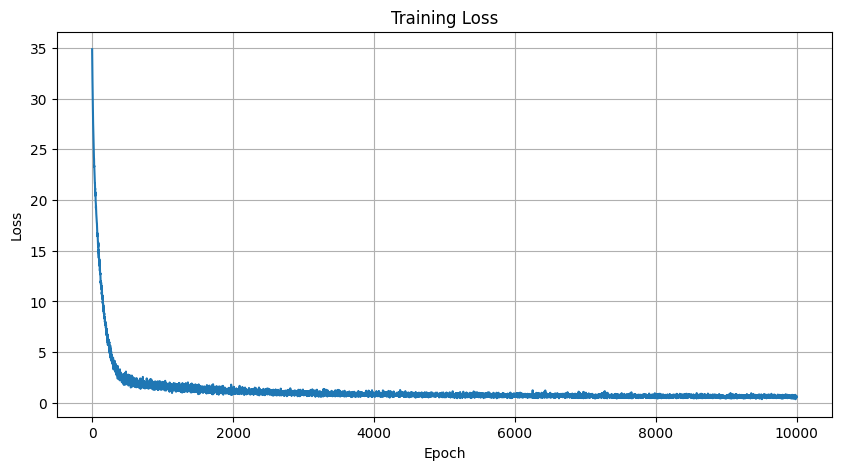

Chart 'prediction_vs_actual_test_set.png' has been saved.


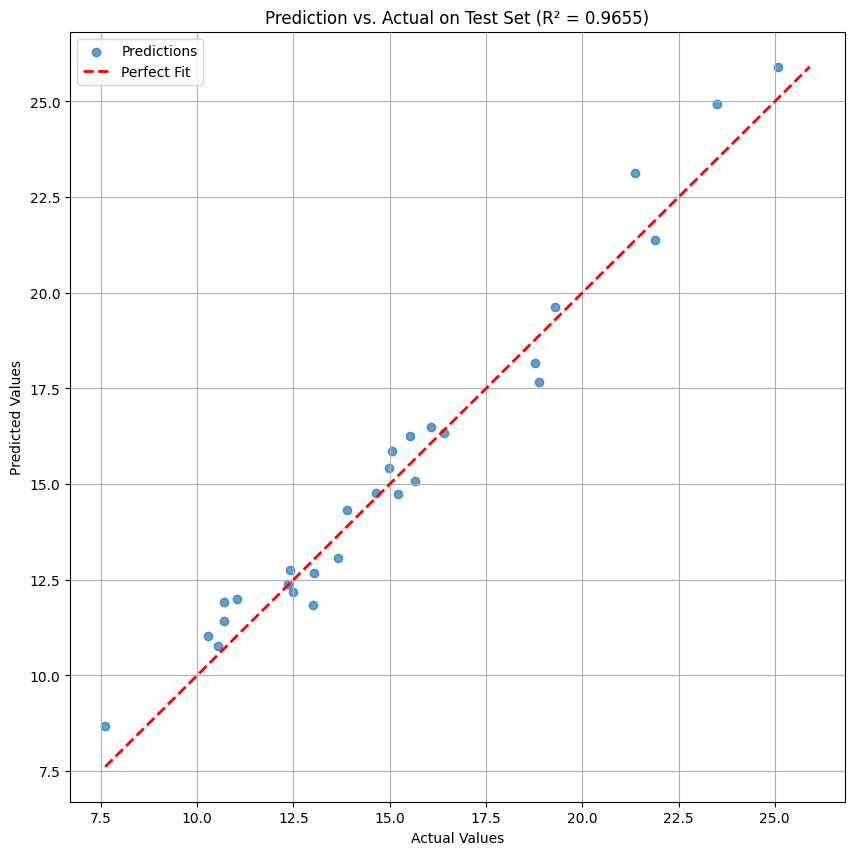

Chart 'residual_plot_test_set.png' has been saved.


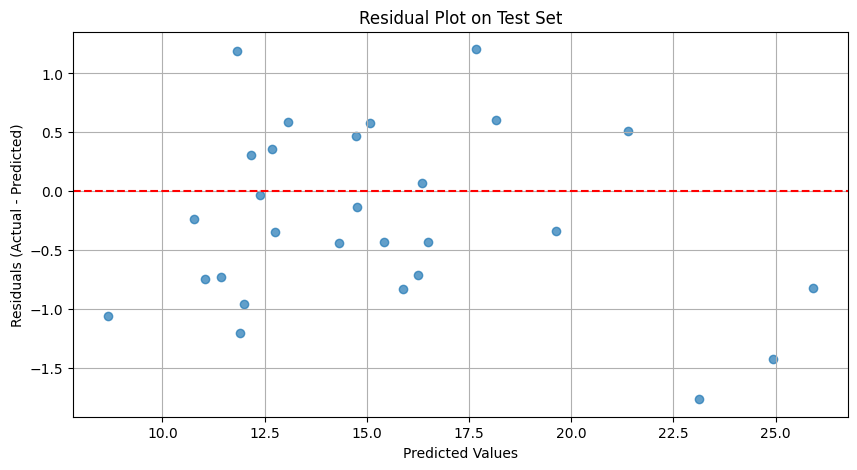


Model and normalization parameters have been saved to 'model_and_norm_params.pth'


In [1]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# --- 1. Load and Prepare Data ---
# Load data
df = pd.read_excel('C:/Users/Administrator/Desktop/SC.xlsx')
features = df.iloc[:, :-1].values  # Convert to NumPy array
targets = df.iloc[:, -1].values    # Convert to NumPy array

# --- Added: Manual Data Split ---
# Set random seed for reproducibility
np.random.seed(42)
# Get all indices and shuffle
indices = np.random.permutation(len(features))
# Determine test set size
test_size = 28
# Split into training and test indices
train_indices = indices[:-test_size]
test_indices = indices[-test_size:]
# Get training and test sets based on indices
X_train, X_test = features[train_indices], features[test_indices]
y_train, y_test = targets[train_indices], targets[test_indices]

print(f"Total data points: {len(features)}")
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# --- Modified: Calculate normalization parameters from training set only ---
# Normalize features and targets (using training set statistics)
# Note: Only features are normalized; targets typically remain unchanged
features_mean = np.mean(X_train, axis=0)
features_std = np.std(X_train, axis=0)
# Prevent division by zero
features_std[features_std == 0] = 1
X_train_normalized = (X_train - features_mean) / features_std
X_test_normalized = (X_test - features_mean) / features_std  # Use training parameters to normalize test set

# Convert to tensors
X_train_tensor = torch.tensor(X_train_normalized, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_normalized, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Store normalization parameters for later use
norm_params = {
    'features_mean': torch.tensor(features_mean, dtype=torch.float32),
    'features_std': torch.tensor(features_std, dtype=torch.float32),
}

# --- Modified: Create Dataset and DataLoader for training and test sets ---
# Create dataset and dataloader for training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=250, shuffle=True)

# Create dataset and dataloader for testing
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
# Test set batch_size can be set to the test set size, shuffle=False
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

# --- 2. Define Model ---
class MyModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),  # Increase neurons
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            nn.Linear(128, 64),  # Add a layer
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# --- 3. Initialize Model, Loss Function, and Optimizer ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = X_train.shape[1]  # Use training set feature count
model = MyModel(input_size=input_size).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# Constants
mu = 0.2
E = 30000
q = 0.007
a = 16000
b = 16000

# Training parameters
num_epochs = 10000
losses = []

# --- 4. Training Loop ---
print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    # --- Modified: Use train_loader ---
    for inputs, targets_batch in train_loader:
        inputs, targets_batch = inputs.to(device), targets_batch.to(device)
        # Forward pass
        outputs = model(inputs)
        # Extract input features
        H_r = inputs[:, 3]
        W_r = inputs[:, 4]
        G_s = inputs[:, 1]
        T = inputs[:, 0]
        H_s = inputs[:, 2]
        # Note: According to original code, W_s and W_r use the same feature column. Verify if this is intended.
        W_s = inputs[:, 4]
        # Calculate intermediate values
        G = E / (2 * (1 + mu))
        t = H_r * W_r / G_s + T
        B_t = E * T / (-mu**2 + 1)
        h = H_s + 2 * t
        D11 = ((h + t)**2 / 2) * B_t
        D12 = mu * ((h + t)**2 / 2) * B_t
        Cx = G_s * W_s * H_s * G / G_s**2
        C = Cx * Cx
        # Calculate w_pr
        trem_1 = 2.297523956e-16
        trem_2 = 5.400823438e-7
        trem_3 = 5.896718750e-7
        trem_4 = 16.76647
        w_pr = (
            (trem_1 * (D11 * D11 - D12**2 - 2 * D12 * 0)) / C
            + (trem_2 * (0 * Cx + D11 * Cx)) / C
            + (trem_3 * (D11 * Cx + 0 * Cx)) / C
            + trem_4
        ).unsqueeze(1)
        # Combine model output with physics-based calculation
        final_output = w_pr + outputs
        # Calculate loss
        loss = criterion(final_output, targets_batch)
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')
print("Training complete!")

# --- 5. Evaluate Model ---
print("\nStarting model evaluation on test set...")
model.eval()  # Set model to evaluation mode
all_preds = []
all_targets = []
with torch.no_grad():  # No gradient calculation to save memory and computation
    for inputs, targets_batch in test_loader:
        inputs, targets_batch = inputs.to(device), targets_batch.to(device)
        # Forward pass
        outputs = model(inputs)
        # --- Copy the same physical calculation logic as in training ---
        H_r = inputs[:, 3]
        W_r = inputs[:, 4]
        G_s = inputs[:, 1]
        T = inputs[:, 0]
        H_s = inputs[:, 2]
        W_s = inputs[:, 4]
        G = E / (2 * (1 + mu))
        t = H_r * W_r / G_s + T
        B_t = E * T / (-mu**2 + 1)
        h = H_s + 2 * t
        D11 = ((h + t)**2 / 2) * B_t
        D12 = mu * ((h + t)**2 / 2) * B_t
        Cx = G_s * W_s * H_s * G / G_s**2
        C = Cx * Cx
        trem_1 = 2.297523956e-16
        trem_2 = 5.400823438e-7
        trem_3 = 5.896718750e-7
        trem_4 = 16.76647
        w_pr = (
            (trem_1 * (D11 * D11 - D12**2 - 2 * D12 * 0)) / C
            + (trem_2 * (0 * Cx + D11 * Cx)) / C
            + (trem_3 * (D11 * Cx + 0 * Cx)) / C
            + trem_4
        ).unsqueeze(1)
        final_output = w_pr + outputs
        all_preds.append(final_output.cpu().numpy())
        all_targets.append(targets_batch.cpu().numpy())

# Merge all batch predictions and targets into single arrays
all_preds = np.concatenate(all_preds).flatten()
all_targets = np.concatenate(all_targets).flatten()

# --- 6. Manually Calculate and Print Performance Metrics ---
# Convert to numpy arrays for calculation
all_preds_np = all_preds
all_targets_np = all_targets
# Manually calculate MSE
mse = np.mean((all_targets_np - all_preds_np)**2)
# Manually calculate MAE
mae = np.mean(np.abs(all_targets_np - all_preds_np))
# Manually calculate R² score
ss_res = np.sum((all_targets_np - all_preds_np)**2)
ss_tot = np.sum((all_targets_np - np.mean(all_targets_np))**2)
r2 = 1 - (ss_res / ss_tot)

print(f"\nTest Set Evaluation Results:")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R² Score: {r2:.6f}")

# --- 7. Plot and Save Charts ---
# Plot and save training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.savefig('training_loss.png')  # Save the image
print("\nChart 'training_loss.png' has been saved.")
plt.show()

# Plot and save Prediction vs. Actual
plt.figure(figsize=(10, 10))
plt.scatter(all_targets, all_preds, alpha=0.7, label='Predictions')
# Plot y=x reference line for perfect prediction
min_val = min(np.min(all_targets), np.min(all_preds))
max_val = max(np.max(all_targets), np.max(all_preds))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Prediction vs. Actual on Test Set (R² = {r2:.4f})')
plt.legend()
plt.grid(True)
plt.savefig('prediction_vs_actual_test_set.png')  # Save the image
print("Chart 'prediction_vs_actual_test_set.png' has been saved.")
plt.show()

# Plot and save Residuals
residuals = all_targets - all_preds
plt.figure(figsize=(10, 5))
plt.scatter(all_preds, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot on Test Set')
plt.grid(True)
plt.savefig('residual_plot_test_set.png')  # Save the image
print("Chart 'residual_plot_test_set.png' has been saved.")
plt.show()

# --- 8. Save Model and Normalization Parameters ---
torch.save({
    'model_state_dict': model.state_dict(),
    'norm_params': norm_params
}, 'model_and_norm_params.pth')
print("\nModel and normalization parameters have been saved to 'model_and_norm_params.pth'")

Using device: cuda
Successfully loaded model and parameters from model_and_norm_params.pth.
Model weights and normalization parameters loaded successfully.
Initial best value: 15.673782
Initial best position: ['63.9436', '1750.4618', '187.2687', '117.2026', '385.6629']
Iteration 10/50: Best value = 12.037210
Iteration 20/50: Best value = 10.697349
Iteration 30/50: Best value = 10.226181
Iteration 40/50: Best value = 9.908243
Iteration 50/50: Best value = 9.878614

Optimization completed!
Final best value: 9.878614
Final best position: ['55.5155', '1500.0000', '250.0000', '150.0000', '300.0000']


C:\Users\Administrator\AppData\Local\Temp\ipykernel_10708\418319972.py:148: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gbest_value = float(pbest_values[gbest_idx])  # Convert to float
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10708\418319972.py:187: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  current_best_value = float(current_values[current_best_idx])


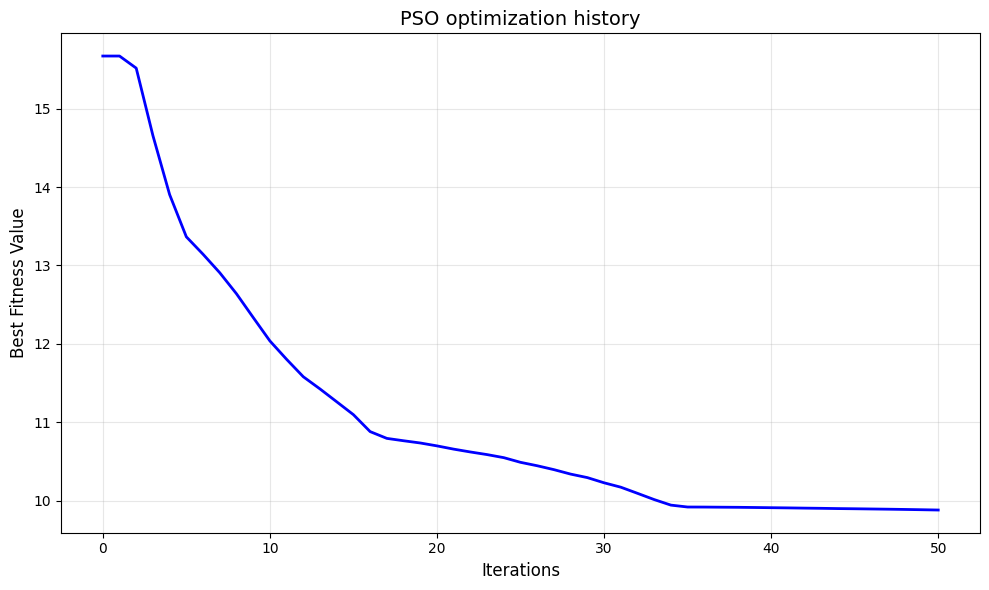


Optimization Results Comparison

Original input: [50.00, 2000.00, 200.00, 100.00, 400.00]
Original output: 17.248571

Optimized input: [55.5155, 1500.0000, 250.0000, 150.0000, 300.0000]
Optimized output: 9.878617

Improvement: 42.73%

Optimization Suggestions
T   :  50.00 →  55.5155 (  11.03%)
G_s : 2000.00 → 1500.0000 ( -25.00%)
H_s : 200.00 → 250.0000 (  25.00%)
H_r : 100.00 → 150.0000 (  50.00%)
W_r : 400.00 → 300.0000 ( -25.00%)


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List

class MyModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.net(x)

class PSOOptimizer:
    """Particle Swarm Optimization Algorithm"""
    
    def __init__(self, 
                 model: MyModel,
                 norm_params: dict,
                 bounds: List[Tuple[float, float]],
                 device: torch.device,
                 n_particles: int = 50,
                 w: float = 0.5,
                 c1: float = 1.5,
                 c2: float = 1.5,
                 max_iter: int = 100):
        """
        Initialize PSO optimizer
        """
        self.model = model
        self.norm_params = norm_params
        self.bounds = bounds
        self.device = device
        self.n_particles = n_particles
        self.w = w
        self.c1 = c1
        self.c2 = c2
        self.max_iter = max_iter
        self.n_dim = len(bounds)
        
        # Model constants
        self.mu = 0.2
        self.E = 30000
        self.q = 0.007
        self.a = 16000
        self.b = 16000
        
    def normalize_features(self, features: torch.Tensor) -> torch.Tensor:
        """Feature normalization"""
        features_mean = self.norm_params['features_mean']
        features_std = self.norm_params['features_std']
        return (features - features_mean) / features_std
    
    def forward_with_physics(self, x: torch.Tensor) -> torch.Tensor:
        """Forward propagation with physics calculations"""
        self.model.eval()
        with torch.no_grad():
            x_normalized = self.normalize_features(x.to(self.device))
            x_normalized = x_normalized.to(self.device)
            
            inputs = x_normalized
            outputs = self.model(inputs)
            
            # Physics calculations
            H_r = inputs[:, 3]
            W_r = inputs[:, 4]
            G_s = inputs[:, 1]
            T = inputs[:, 0]
            H_s = inputs[:, 2]
            W_s = inputs[:, 4]
            G = self.E / (2 * (1 + self.mu))
            t = H_r * W_r / G_s + T
            B_t = self.E * T / (-self.mu**2 + 1)
            h = H_s + 2 * t
            D11 = ((h + t)**2 / 2) * B_t
            D12 = self.mu * ((h + t)**2 / 2) * B_t
            Cx = G_s * W_s * H_s * G / G_s**2
            C = Cx * Cx
            trem_1 = 2.297523956e-16
            trem_2 = 5.400823438e-7
            trem_3 = 5.896718750e-7
            trem_4 = 16.76647
            w_pr = (
                (trem_1 * (D11 * D11 - D12**2 - 2 * D12 * 0)) / C
                + (trem_2 * (0 * Cx + D11 * Cx)) / C
                + (trem_3 * (D11 * Cx + 0 * Cx)) / C
                + trem_4
            ).unsqueeze(1)
            final_output = w_pr + outputs
            return final_output
    
    def objective_function(self, x: np.ndarray) -> np.ndarray:
        """Objective function: Calculate fitness value (minimize)"""
        x_tensor = torch.tensor(x, dtype=torch.float32).to(self.device)
        if len(x_tensor.shape) == 1:
            x_tensor = x_tensor.unsqueeze(0)
        
        with torch.no_grad():
            outputs = self.forward_with_physics(x_tensor)
        
        return outputs.cpu().numpy()
    
    def initialize_particles(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Initialize particle positions, velocities, and best positions"""
        # Initialize positions
        positions = np.zeros((self.n_particles, self.n_dim))
        for i in range(self.n_dim):
            min_val, max_val = self.bounds[i]
            positions[:, i] = np.random.uniform(min_val, max_val, self.n_particles)
        
        # Initialize velocities
        velocities = np.random.uniform(-1, 1, (self.n_particles, self.n_dim))
        
        # Initialize personal best positions
        pbest_positions = positions.copy()
        pbest_values = self.objective_function(positions)
        
        return positions, velocities, pbest_positions, pbest_values
    
    def optimize(self, verbose: bool = True) -> Tuple[np.ndarray, float, List[float]]:
        """Execute PSO optimization
        
        Returns:
            best_position: Optimal parameter combination
            best_value: Optimal fitness value
            history: Optimization history
        """
        # Initialize particles
        positions, velocities, pbest_positions, pbest_values = self.initialize_particles()
        
        # Initialize global best
        gbest_idx = np.argmin(pbest_values)
        gbest_position = pbest_positions[gbest_idx].copy()
        gbest_value = float(pbest_values[gbest_idx])  # Convert to float
        
        # Record optimization history
        history = [gbest_value]
        
        if verbose:
            print(f"Initial best value: {gbest_value:.6f}")
            print(f"Initial best position: {[f'{x:.4f}' for x in gbest_position]}")
        
        # Start optimization iterations
        for iteration in range(self.max_iter):
            # Update particle velocities and positions
            r1, r2 = np.random.random((2, self.n_particles, self.n_dim))
            
            velocities = (self.w * velocities +
                         self.c1 * r1 * (pbest_positions - positions) +
                         self.c2 * r2 * (gbest_position - positions))
            
            # Limit velocity range
            max_velocity = 0.1 * np.array([max_val - min_val for min_val, max_val in self.bounds])
            velocities = np.clip(velocities, -max_velocity, max_velocity)
            
            positions += velocities
            
            # Boundary handling
            for i in range(self.n_dim):
                min_val, max_val = self.bounds[i]
                positions[:, i] = np.clip(positions[:, i], min_val, max_val)
            
            # Calculate fitness for new positions
            current_values = self.objective_function(positions)
            
            # Update personal best
            improved_idx = current_values.flatten() < pbest_values.flatten()
            pbest_positions[improved_idx] = positions[improved_idx]
            pbest_values[improved_idx] = current_values[improved_idx]
            
            # Update global best
            current_best_idx = np.argmin(current_values)
            current_best_value = float(current_values[current_best_idx])
            
            if current_best_value < gbest_value:
                gbest_position = positions[current_best_idx].copy()
                gbest_value = current_best_value
                
                if verbose and (iteration + 1) % 10 == 0:
                    print(f"Iteration {iteration + 1}/{self.max_iter}: "
                          f"Best value = {gbest_value:.6f}")
            
            history.append(gbest_value)
        
        if verbose:
            print(f"\nOptimization completed!")
            print(f"Final best value: {gbest_value:.6f}")
            print(f"Final best position: {[f'{x:.4f}' for x in gbest_position]}")
        
        return gbest_position, gbest_value, history
    
    def plot_optimization_history(self, history: List[float]):
        """Plot optimization history"""
        plt.figure(figsize=(10, 6))
        plt.plot(history, 'b-', linewidth=2)
        plt.xlabel('Iterations', fontsize=12)
        plt.ylabel('Best Fitness Value', fontsize=12)
        plt.title('PSO optimization history', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig("./result_1.jpg", dpi=300, bbox_inches='tight')
        plt.show()
# --- Main program ---
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Create model
    model = MyModel(input_size=5).to(device)
    checkpoint_path = 'model_and_norm_params.pth'
    
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        print(f"Successfully loaded model and parameters from {checkpoint_path}.")
    except FileNotFoundError:
        print(f"Error: File {checkpoint_path} not found. Please ensure the file path is correct.")
        exit()
    
    # Load model and normalization parameters
    model.load_state_dict(checkpoint['model_state_dict'])
    norm_params = checkpoint['norm_params']
    print("Model weights and normalization parameters loaded successfully.")
    
    # Define search bounds
    # Feature order: [T, G_s, H_s, H_r, W_r]
    bounds = [
        (50, 100),     # T
        (1500, 2500),  # G_s
        (150, 250),    # H_s
        (50, 150),     # H_r
        (300, 500)     # W_r
    ]
    
    # Create PSO optimizer
    pso_optimizer = PSOOptimizer(
        model=model,
        norm_params=norm_params,
        bounds=bounds,
        device=device,
        n_particles=30,
        w=0.5,
        c1=1.5,
        c2=1.5,
        max_iter=50
    )
    
    # Execute optimization
    best_position, best_value, history = pso_optimizer.optimize(verbose=True)
    
    # Plot optimization history
    pso_optimizer.plot_optimization_history(history)
    
    # Compare before and after optimization
    print("\n" + "="*50)
    print("Optimization Results Comparison")
    print("="*50)
    
    # Original input
    x_test = torch.tensor([50, 2000, 200, 100, 400], dtype=torch.float32)
    x_test = x_test.view(1, -1)
    
    # Original prediction
    original_output = pso_optimizer.forward_with_physics(x_test.to(device))
    original_output_value = float(original_output)
    
    # Optimized prediction
    x_optimized = torch.tensor(best_position, dtype=torch.float32).view(1, -1)
    optimized_output = pso_optimizer.forward_with_physics(x_optimized.to(device))
    optimized_output_value = float(optimized_output)
    
    # Format output
    original_input_str = ', '.join([f'{x:.2f}' for x in x_test.numpy().flatten()])
    optimized_input_str = ', '.join([f'{x:.4f}' for x in best_position])
    
    print(f"\nOriginal input: [{original_input_str}]")
    print(f"Original output: {original_output_value:.6f}")
    
    print(f"\nOptimized input: [{optimized_input_str}]")
    print(f"Optimized output: {optimized_output_value:.6f}")
    
    # Calculate improvement
    if original_output_value != 0:
        improvement = ((original_output_value - optimized_output_value) / original_output_value * 100)
        print(f"\nImprovement: {improvement:.2f}%")
    else:
        print(f"\nImprovement: N/A (original output is 0)")
    
    # Output optimization suggestions
    print("\n" + "="*50)
    print("Optimization Suggestions")
    print("="*50)
    
    feature_names = ["T", "G_s", "H_s", "H_r", "W_r"]
    original_values = x_test.numpy().flatten()
    
    for i, (name, orig, opt) in enumerate(zip(feature_names, original_values, best_position)):
        change = ((opt - orig) / orig * 100) if orig != 0 else 0
        print(f"{name:4s}: {orig:6.2f} → {opt:8.4f} ({change:7.2f}%)")